In [1]:
import csv
import sys

import matplotlib.pyplot as plt
import numpy as np

In [2]:
circuit_family = "RND"
if circuit_family=="RND":
    qubits=[8,10,12]
else:
    qubits=[5,15,25]
circuits = [circuit_family+str(qubit) for qubit in qubits]

istates=[]
ostates=[]
nsamples=[]
nthreads=[]
for circuit in circuits:
    match circuit:
        case  "SU5":
            istate = "0"
            ostate = "0"
            samples = "25"
            threads = "16"
        case  "SU15":
            istate = "0"
            ostate = "0"
            samples = "32"
            threads = "128"
        case  "SU25":
            istate = "0"
            ostate = "0"
            samples = "36"
            threads = "128"
        case  "IQP5":
            istate = "0"
            ostate = "0"
            samples = "25"
            threads = "128"
        case  "IQP15":
            istate = "0"
            ostate = "0"
            samples = "33"
            threads = "128"
        case  "IQP25":
            istate = "0"
            ostate = "0"
            samples = "36"
            threads = "128"
        case  "RND8":
            istate = "0"
            ostate = "0"
            samples = "26"
            threads = "64"
        case  "RND10":
            istate = "0"
            ostate = "0"
            samples = "27"
            threads = "128"
        case  "RND12":
            istate = "0"
            ostate = "16"
            samples = "39"
            threads = "128"
    istates.append(istate)
    ostates.append(ostate)
    nsamples.append(samples)
    nthreads.append(threads)
    

algorithms = ["IS","BD_MIS"]

files = []
for ndx, circuit in enumerate(circuits):
    path = "../circuits/"+circuit+"/ExecutionData/"
    files.extend([path + circuit + ".data_stats_" + alg + "_V_SP_" + istates[ndx] + "_" + ostates[ndx] + "_" + nsamples[ndx] + "_" + nthreads[ndx] + "_average.csv" for alg in algorithms])

print (files)

['../circuits/RND8/ExecutionData/RND8.data_stats_IS_V_SP_0_0_26_64_average.csv', '../circuits/RND8/ExecutionData/RND8.data_stats_BD_MIS_V_SP_0_0_26_64_average.csv', '../circuits/RND10/ExecutionData/RND10.data_stats_IS_V_SP_0_0_27_128_average.csv', '../circuits/RND10/ExecutionData/RND10.data_stats_BD_MIS_V_SP_0_0_27_128_average.csv', '../circuits/RND12/ExecutionData/RND12.data_stats_IS_V_SP_0_16_39_128_average.csv', '../circuits/RND12/ExecutionData/RND12.data_stats_BD_MIS_V_SP_0_16_39_128_average.csv']


In [3]:
# Read CSVs

data = {}
ndxfile = 0
for circuit in circuits:
    data[circuit]={}
    for alg in algorithms:
        file = files[ndxfile]
        ndxfile = ndxfile +1
        data[circuit][alg] = {}
        #print ('circuit is ', circuit, '; Alg is ', alg, '; file is ', file)
        with open(file) as csvfile:
            csvreader = csv.reader(csvfile, delimiter=',')
            for rowndx, row in enumerate(csvreader):
                #print (row)
                if rowndx==0: continue     # 1st row is header
                elif rowndx==1:
                    true_w = complex(float(row[0]),float(row[1]))
                    data[circuit][alg]["true_w"] = true_w  
                    #print ("True w = ", true_w)
                elif rowndx==2:     # 3rd row is header
                    dataTitles = [s.strip() for s in row]
                    dataTitles.remove("RvarianceR")
                    dataTitles.remove("RvarianceI")
                    # add 3 more attributes
                    #dataTitles.append ("variance")
                    #dataTitles.append ("L2")
                    dataTitles.append ("efficiency")
                    for title in dataTitles:
                        data[circuit][alg][title] = [] 
                    #print(dataTitles)
                else:
                    #print (row)
                    for titlendx, title in enumerate(dataTitles):
                        if titlendx <10:
                            data[circuit][alg][title].append(float(row[titlendx])) 
                        elif titlendx == 10:   # efficiency
                            time = (float(row[1]))
                            variance = (float(row[7]))
                            if variance > 0.:
                                efficiency = 1./(time*variance)
                            else:
                                efficiency = sys.float_info.max
                            data[circuit][alg]["efficiency"].append(efficiency)
    

In [4]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

CONVOLVE_NEIGH = 25

In [5]:
## Plot allows specification of dependent and in dependent variables
# choose each from
'n_samples', 'time', 'n_paths', 'n_NZero_paths', 'estimateR', 'estimateI', 'varianceR', 'varianceI', 'var', 'L2', 'efficiency'
# independent variable
X_var = 'n_paths'
# dependent variable
Y_var = 'var'

# log X axis ?
log_X_axis = True
# log Y axis ?
log_Y_axis = True


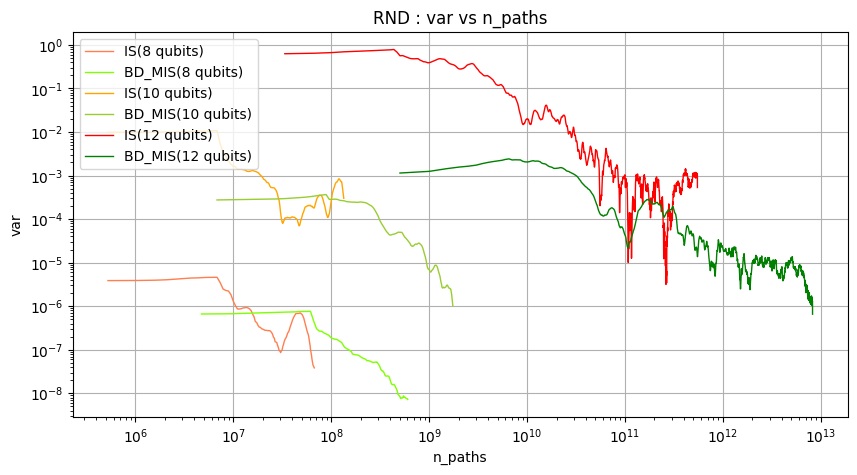

In [6]:
fig, ax = plt.subplots()
fig.set_size_inches (10,5)
#fig, ax = figure(figsize=(8, 6), dpi=100)

if log_X_axis:
    # convert x-axis to Logarithmic scale
    plt.xscale("log")
else:
    plt.xscale("linear")


if log_Y_axis:
    # convert y-axis to Logarithmic scale
    plt.yscale("log")
else:
    plt.yscale("linear")

red_colors = ["#FF7F50","#FFA500","#FF0000"]
green_colors = ["#7FFF00","#9ACD32","#008000"]
# for each circuit
for circ_ndx, circuit in enumerate(circuits):
    # for each algorithm
    for alg in algorithms:
        # Data for plotting
        X = data[circuit][alg][X_var]
        Y_raw = data[circuit][alg][Y_var]
        Y = smooth(Y_raw, CONVOLVE_NEIGH)

        qubit = qubits[circ_ndx]
        ax.plot(X, Y, label = alg + "("+str(qubit)+" qubits)", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

        #Regression
        # Add regression line to plot
        #coefficients = np.polyfit(X, Y, 1)
        #line = np.poly1d(coefficients)
        #ax.plot(X, line(X), ':', label = alg + "("+str(qubit)+" qubits) - Reg", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

ax.set(xlabel=X_var, ylabel=Y_var,
     title=circuit_family + " : " + Y_var + ' vs ' + X_var)

ax.grid()
ax.legend ()


plt.show()

In [7]:
img = "../circuits/graphics/"+circuit_family + "_" + X_var + "_VS_" + Y_var + ".png"
fig.savefig(img)

In [8]:
## Plot allows specification of dependent and in dependent variables
# choose each from
'n_samples', 'time', 'n_paths', 'n_NZero_paths', 'estimateR', 'estimateI', 'varianceR', 'varianceI', 'var', 'L2', 'efficiency'
# independent variable
X_var = 'time'
# dependent variable
Y_var = 'var'

# log X axis ?
log_X_axis = True
# log Y axis ?
log_Y_axis = True


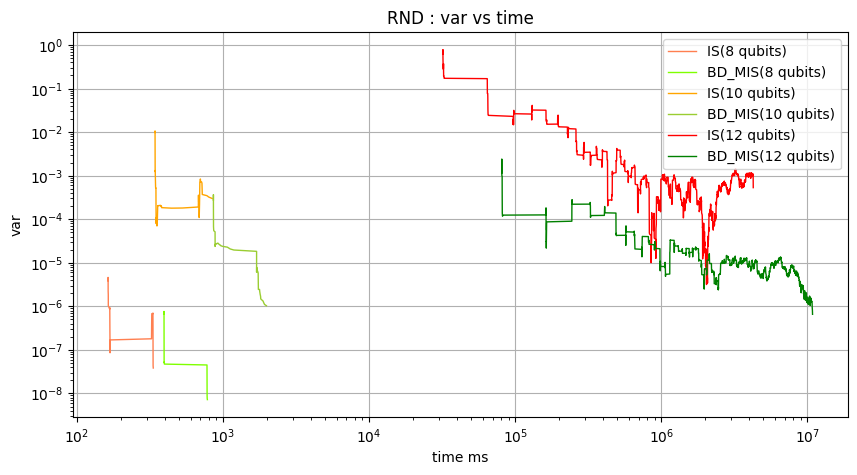

In [9]:
fig, ax = plt.subplots()
fig.set_size_inches (10,5)
#fig, ax = figure(figsize=(8, 6), dpi=100)

if log_X_axis:
    # convert x-axis to Logarithmic scale
    plt.xscale("log")
else:
    plt.xscale("linear")


if log_Y_axis:
    # convert y-axis to Logarithmic scale
    plt.yscale("log")
else:
    plt.yscale("linear")

red_colors = ["#FF7F50","#FFA500","#FF0000"]
green_colors = ["#7FFF00","#9ACD32","#008000"]
# for each circuit
for circ_ndx, circuit in enumerate(circuits):
    # for each algorithm
    for alg in algorithms:
        # Data for plotting
        X = [x / 1000. for x in data[circuit][alg][X_var]]
        Y_raw = data[circuit][alg][Y_var]
        Y = smooth(Y_raw, CONVOLVE_NEIGH)

        qubit = qubits[circ_ndx]
        ax.plot(X, Y, label = alg + "("+str(qubit)+" qubits)", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

        #Regression
        # Add regression line to plot
        #coefficients = np.polyfit(X, Y, 1)
        #line = np.poly1d(coefficients)
        #ax.plot(X, line(X), ':', label = alg + "("+str(qubit)+" qubits) - Reg", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

ax.set(xlabel=X_var + " ms", ylabel=Y_var,
     title=circuit_family + " : " + Y_var + ' vs ' + X_var)

ax.grid()
ax.legend (loc='upper right')


plt.show()

In [10]:
img = "../circuits/graphics/"+circuit_family + "_" + X_var + "_VS_" + Y_var + ".png"
fig.savefig(img)

In [11]:
## Plot allows specification of dependent and in dependent variables
# choose each from
'n_samples', 'time', 'n_paths', 'n_NZero_paths', 'estimateR', 'estimateI', 'varianceR', 'varianceI', 'var', 'L2', 'efficiency'
# independent variable
X_var = 'n_paths'
# dependent variable
Y_var = 'efficiency'

# log X axis ?
log_X_axis = True
# log Y axis ?
log_Y_axis = True


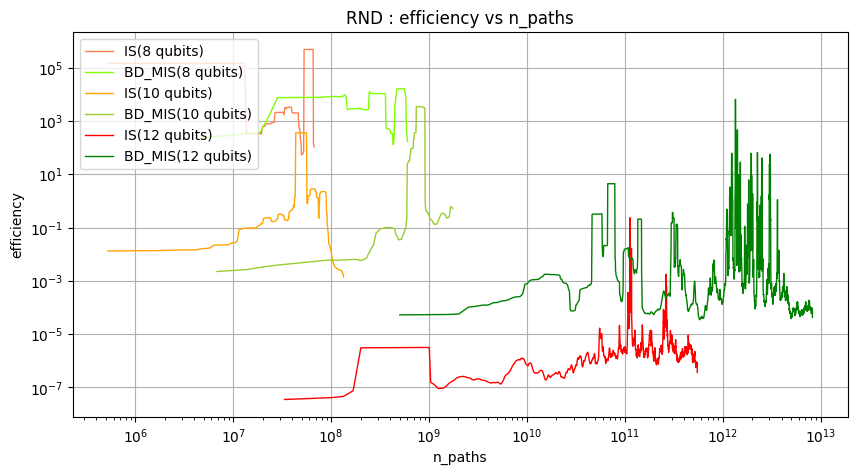

In [12]:
fig, ax = plt.subplots()
fig.set_size_inches (10,5)
#fig, ax = figure(figsize=(8, 6), dpi=100)

if log_X_axis:
    # convert x-axis to Logarithmic scale
    plt.xscale("log")
else:
    plt.xscale("linear")


if log_Y_axis:
    # convert y-axis to Logarithmic scale
    plt.yscale("log")
else:
    plt.yscale("linear")

red_colors = ["#FF7F50","#FFA500","#FF0000"]
green_colors = ["#7FFF00","#9ACD32","#008000"]
# for each circuit
for circ_ndx, circuit in enumerate(circuits):
    # for each algorithm
    for alg in algorithms:
        # Data for plotting
        X = data[circuit][alg][X_var]
        Y_raw = data[circuit][alg][Y_var]
        Y = smooth(Y_raw, CONVOLVE_NEIGH)

        qubit = qubits[circ_ndx]
        ax.plot(X, Y, label = alg + "("+str(qubit)+" qubits)", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

        #Regression
        # Add regression line to plot
        #coefficients = np.polyfit(X, Y, 1)
        #line = np.poly1d(coefficients)
        #ax.plot(X, line(X), ':', label = alg + "("+str(qubit)+" qubits) - Reg", color= red_colors[circ_ndx] if alg == 'IS' else green_colors[circ_ndx], linewidth=1)

ax.set(xlabel=X_var, ylabel=Y_var,
     title=circuit_family + " : " + Y_var + ' vs ' + X_var)

ax.grid()
ax.legend (loc='upper left')


plt.show()

In [13]:
img = "../circuits/graphics/"+circuit_family + "_" + X_var + "_VS_" + Y_var + ".png"
fig.savefig(img)

In [14]:
print ("That\'s all, folks!")

That's all, folks!
